In [1]:
import sqlite3
import numpy as np
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect('molecular_descriptorsAML9.6.db')
cursor = conn.cursor()

In [3]:
# 假设表名为 'your_table'，特征列名为 'feature1', 'feature2'，目标列名为 'target'
# 你需要根据实际情况修改这些名称
query = "SELECT * FROM data "
cursor.execute(query)
df = pd.read_sql(query, conn)
df1 = df.drop(columns="SMILES")

# 关闭数据库连接
conn.close()


In [4]:
# 1. 逐元素检查是否为空字符串，返回布尔值矩阵
mask = df1.apply(lambda col: col.map(lambda x: x == ''))

# 2. 按行检查是否存在True（空字符串）
rows_with_empty = mask.any(axis=1)

# 3. 删除包含空字符串的行
df2 = df1[~rows_with_empty]

# 重置索引（删除原索引，生成新的连续整数索引）
df2 = df2.reset_index(drop=True)


In [5]:
print(df1)
print(df2)

                  MolWt NumAtoms NumBonds NumHAcceptors NumHDonors  \
0                135.13       10       11             4          2   
1     702.6070000000002       48       51             6          3   
2               625.562       42       41             4          8   
3    262.35299999999995       19       20             4          0   
4    387.82000000000005       25       25             4          0   
..                  ...      ...      ...           ...        ...   
506   448.5270000000003       33       36             7          3   
507   512.5660000000001       37       42             5          2   
508  510.57500000000016       37       41             6          2   
509   501.9630000000003       35       39             8          2   
510   386.2740000000001       23       25             5          0   

    NumRotatableBonds                TPSA          ExactMolWt  \
0                   0   80.47999999999999        135.05449516   
1                  10  136.48

In [6]:
mapping = {"active": 1, "Inactive": 0}
df2["Activity2"] = df2["Activity"].map(mapping).fillna(0)
df2= df2.drop(columns = "Activity")


In [7]:
# 将数据转换为NumPy数组
data = np.array(df2)
X = data[:, :-1].astype(float)  # 特征
y = data[:, -1].astype(float)   # 目标


In [8]:
print(len(X))

490


In [9]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
print(len(X_test))
print(len(y_test))

147
147


In [11]:
# 计算正负样本比例，模拟class_weight="balanced"的效果
# 当class_weight="balanced"时，权重与类别频率成反比
# 对于二分类问题，这相当于scale_pos_weight = 负样本数 / 正样本数
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos  # 这相当于实现了balanced的效果

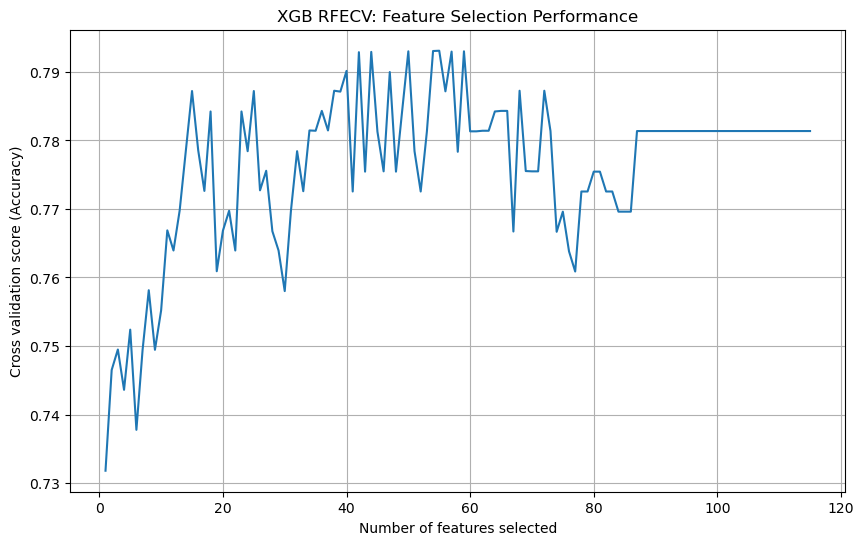

最佳特征数量: 59
选择的特征掩码: [ True False False False False  True  True False False  True False  True
 False  True  True False  True  True  True False False  True  True  True
  True  True  True  True  True  True  True  True  True  True False  True
 False False  True  True False  True  True  True  True  True  True  True
  True False False  True  True False False False False  True  True  True
  True  True  True False False  True False False False False  True False
 False False  True False False False False  True  True False  True False
 False False False  True False  True  True False False  True  True False
 False False False  True False  True  True  True  True False False False
 False False False False False False False False False False  True]
特征排名: [ 1 42  2  5 37  1  1 36 15  1 53  1 35  1  1 49  1  1  1 39 43  1  1  1
  1  1  1  1  1  1  1  1  1  1 26  1 57 28  1  1  9  1  1  1  1  1  1  1
  1 20 24  1  1 44 33 11 32  1  1  1  1  1  1 30  4  1 55 12 19 16  1  8
 40 38  1 31 21 23 13  1  1 29

In [12]:
# 第一步：使用递归特征消除与交叉验证（RFECV）选择最佳特征
# 创建XGBoost模型并设置参数
model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,  # 这里设置了类似class_weight="balanced"的效果
    random_state=42
)

# 创建5折交叉验证
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 创建RFECV对象
rfecv = RFECV(
    estimator=model,
    step=1,  # 每次迭代移除一个特征
    cv=cv,
    scoring='accuracy',
    min_features_to_select=5,
    n_jobs=-1
)

# 执行递归特征消除
rfecv.fit(X_train, y_train)

# 绘制 RFECV 性能曲线
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (Accuracy)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.grid(True)
plt.title('XGB RFECV: Feature Selection Performance')
plt.show()

# 输出特征选择结果
print(f"最佳特征数量: {rfecv.n_features_}")
print(f"选择的特征掩码: {rfecv.support_}")
print(f"特征排名: {rfecv.ranking_}")

# 获取选择的特征
X_train_selected = rfecv.transform(X_train)
X_test_selected = rfecv.transform(X_test)

In [13]:
# 第二步：网格搜索优化随机森林超参数
# 创建XGBoost模型并设置参数
model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,  # 这里设置了类似class_weight="balanced"的效果
    random_state=42
)

# 定义要搜索的参数网格
param_grid = {
    # 树的数量和深度
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    
    # 学习率和子采样
    'learning_rate': [0.01, 0.1, 1],
    'subsample': [0.8, 0.9, 1.0],
    
    # 正则化参数
    'reg_alpha': [0, 0.5, 1],
    'reg_lambda': [1, 1.5, 2]
}


# 初始化网格搜索，使用5折交叉验证
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # 使用所有可用的CPU核心
    verbose=1  # 输出搜索过程信息
)

# 在训练集上执行网格搜索
grid_search.fit(X_train_selected, y_train)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'reg_alpha': [0, 0.5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [14]:
# 输出最佳参数
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证分数: {grid_search.best_score_:.4f}")

最佳参数: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1.5, 'subsample': 0.8}
最佳交叉验证分数: 0.8251


In [15]:
# 第三步：使用最佳参数训练最终模型
# 使用最佳参数创建模型
best_model = grid_search.best_estimator_

# 在训练集上训练最终模型
best_model.fit(X_train_selected, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
# 第四步：模型评估
# 预测
y_pred = best_model.predict(X_test_selected)
y_pred_proba = best_model.predict_proba(X_test_selected)

# 计算评估指标
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"测试集准确率: {accuracy:.4f}")
print(f"精确率: {precision:.4f}")
print(f"召回率: {recall:.4f}")
print(f"F1分数: {f1:.4f}")

# 交叉验证评估
cv_scores = cross_val_score(best_model, X_train_selected, y_train, cv=cv, scoring='accuracy')
print(f"交叉验证准确率: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# 详细分类报告
print("\n分类报告:")
print(classification_report(y_test, y_pred,digits=4))

测试集准确率: 0.7687
精确率: 0.7521
召回率: 0.7687
F1分数: 0.7563
交叉验证准确率: 0.7756 (±0.0452)

分类报告:
              precision    recall  f1-score   support

         0.0     0.8151    0.8899    0.8509       109
         1.0     0.5714    0.4211    0.4848        38

    accuracy                         0.7687       147
   macro avg     0.6933    0.6555    0.6679       147
weighted avg     0.7521    0.7687    0.7563       147



In [18]:
# 打印混淆矩阵（可选）
print("\n混淆矩阵 (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))


混淆矩阵 (Confusion Matrix):
[[97 12]
 [22 16]]


In [17]:
###保存预测概率
# 对于二分类问题，我们通常需要正类的概率
y_pred_proba_model3 = y_pred_proba[:, 1]

# 保存结果
# 建议将真实标签也一起保存，虽然它们应该是相同的，但这样更保险
results_model3 = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba_model3': y_pred_proba_model3
})

# 将结果保存到一个CSV文件
results_model3.to_csv('D:\\AAA科研——高老师\\AML-论文撰写资料\\model3_results.csv', index=False)
print("xgb results exported successfully.")

xgb results exported successfully.


In [1]:
#绘制ROC曲线图
y_pred_proba = best_model.predict_proba(X_test_selected)[:, 1]

# 计算ROC曲线的假正例率(FPR)和真正例率(TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 计算ROC-AUC值
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC值: {roc_auc:.4f}")

# 绘制ROC曲线
plt.figure(figsize=(10, 8))
# 绘制随机森林的ROC曲线
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
# 绘制随机猜测的基准线（对角线）
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 设置图表属性
# 设置刻度标签字体
plt.xticks(fontfamily='Arial')
plt.yticks(fontfamily='Arial')
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate', fontfamily='Arial', fontsize=14)
plt.ylabel('True Positive Rate', fontfamily='Arial', fontsize=14)
plt.title('XGB ROC Curve',fontfamily='Arial', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", prop={'family': 'Arial', 'size': 12})

# 5. 保存图片
plt.tight_layout()
plt.savefig('XGB roc_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()

NameError: name 'best_model' is not defined

In [ ]:
#绘制学习曲线，以判断有无过拟合
# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
sns.set_style("whitegrid")

def plot_svm_learning_curve(estimator, X_train, y_train, model_name="XGB Model", 
                           cv=5, figsize=(12, 8), save_path="XGB_learning_curve.png"):
    """
    Plot learning curve for SVM model and check for overfitting
    """

    # Define training sizes
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    # Calculate learning curve - FIXED: use estimator instead of model
    print("Calculating learning curve...")
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,  # ✅ 修正：使用 estimator 而不是 model
        X=X_train, 
        y=y_train,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        shuffle=True
    )
    
    # Calculate mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot training scores
    ax.plot(train_sizes, train_mean, 'o-', color='#2E86AB', 
            label='Training Score', linewidth=3, markersize=8, 
            markerfacecolor='white', markeredgewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                    alpha=0.2, color='#2E86AB', label='Training ± 1 std')
    
    # Plot validation scores
    ax.plot(train_sizes, val_mean, 's-', color='#A23B72', 
            label='Validation Score', linewidth=3, markersize=8, 
            markerfacecolor='white', markeredgewidth=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                    alpha=0.2, color='#A23B72', label='Validation ± 1 std')
    
    # Set labels and title
    ax.set_title(f'Learning Curve - {model_name}', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Number of Training Examples', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy Score', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=12, frameon=True, fancybox=True, shadow=True)
    
    # Set grid and limits
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 1.05)
    
    # Calculate performance metrics
    final_train_score = train_mean[-1]
    final_val_score = val_mean[-1]
    performance_gap = final_train_score - final_val_score
    gap_percentage = (performance_gap / final_train_score) * 100
    
    # Add performance gap annotation
    bbox_props = dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8, edgecolor="black")
    ax.annotate(f'Performance Gap: {performance_gap:.3f}\n({gap_percentage:.1f}%)', 
                xy=(train_sizes[-1], (final_train_score + final_val_score)/2),
                xytext=(train_sizes[int(len(train_sizes)*0.6)], 0.55),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.3', 
                              color='red', lw=2),
                fontsize=11, fontweight='bold',
                bbox=bbox_props,
                ha='center')
    
    # Add model performance info
    model_info = (f"Final Training Score: {final_train_score:.4f}\n"
                 f"Final Validation Score: {final_val_score:.4f}\n"
                 f"Performance Gap: {performance_gap:.4f}")
    
    ax.text(0.02, 0.98, model_info, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(facecolor='lightblue', alpha=0.7, boxstyle="round,pad=0.5"))
    
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Learning curve saved as: {save_path}")
    
    plt.show()
    
    # Print detailed analysis
    print("\n" + "="*70)
    print("SVM MODEL LEARNING CURVE ANALYSIS")
    print("="*70)
    print(f"{'Metric':<25} {'Value':<15}")
    print(f"{'-'*40}")
    print(f"{'Final Training Score':<25} {final_train_score:.4f}")
    print(f"{'Final Validation Score':<25} {final_val_score:.4f}")
    print(f"{'Performance Gap':<25} {performance_gap:.4f}")
    print(f"{'Relative Decrease':<25} {gap_percentage:.1f}%")
    print(f"{'Diagnosis':<25} {status}")
    print("\nRecommendations:")
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")
    
    return {
        'train_sizes': train_sizes,
        'train_scores': train_mean,
        'val_scores': val_mean,
        'performance_gap': performance_gap,
        'status': status
    }

# 正确的使用示例
if __name__ == "__main__":
    # 首先需要定义这些变量（根据你的实际情况）
    # 正确的函数调用方式
    results = plot_svm_learning_curve(
        estimator=best_model,          # ✅ 使用正确的参数名
        X_train=X_train_selected,    # ✅ 正确的参数顺序
        y_train=y_train,       # ✅ 正确的参数顺序
        model_name="XGB Model",
        cv=5,
        save_path="my_XGB_learning_curve.png"
    )